# Aerial Object Classification & Detection

This notebook implements the internship project: binary classification (Bird vs Drone) using a Custom CNN and Transfer Learning, plus optional notes for YOLOv8 object detection and Streamlit deployment.

Follow cells in order. The notebook auto-checks for required packages and can perform a small test run to validate cells quickly.

In [1]:
# 1) Import required libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as exc:
    raise RuntimeError(
        "TensorFlow import failed in the current kernel. Select a Python 3.11 kernel (recommended: C:/venvs/aerial311/Scripts/python.exe) and retry."
    ) from exc

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('✓ All imports successful')
print(f'✓ TensorFlow version: {tf.__version__}')
print(f'✓ Python version: {sys.version}')

✓ All imports successful
✓ TensorFlow version: 2.20.0
✓ Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
# 2) Dataset paths and basic inspection
from pathlib import Path

candidate_base_dirs = [Path('classification_dataset'), Path('../classification_dataset')]
base_dir = next((p for p in candidate_base_dirs if p.exists()), candidate_base_dirs[0])
train_dir = base_dir / 'train'
valid_dir = base_dir / 'valid'
test_dir = base_dir / 'test'
print('Base path:', base_dir.resolve())

def count_images(folder):
    counts = {}
    if not folder.exists():
        return counts
    for c in folder.iterdir():
        if c.is_dir():
            counts[c.name] = len(list(c.glob('*.jpg'))) + len(list(c.glob('*.jpeg'))) + len(list(c.glob('*.png')))
    return counts

train_counts = count_images(train_dir)
valid_counts = count_images(valid_dir)
test_counts = count_images(test_dir)
print('Train counts:', train_counts)
print('Valid counts:', valid_counts)
print('Test counts:', test_counts)

Base path: C:\Users\singh\OneDrive\Desktop\Ayush\coding\internship\Aerial Object Classification & Detection\classification_dataset
Train counts: {'bird': 1414, 'drone': 1248}
Valid counts: {'bird': 217, 'drone': 225}
Test counts: {'bird': 121, 'drone': 94, 'images': 224, 'labels': 0}


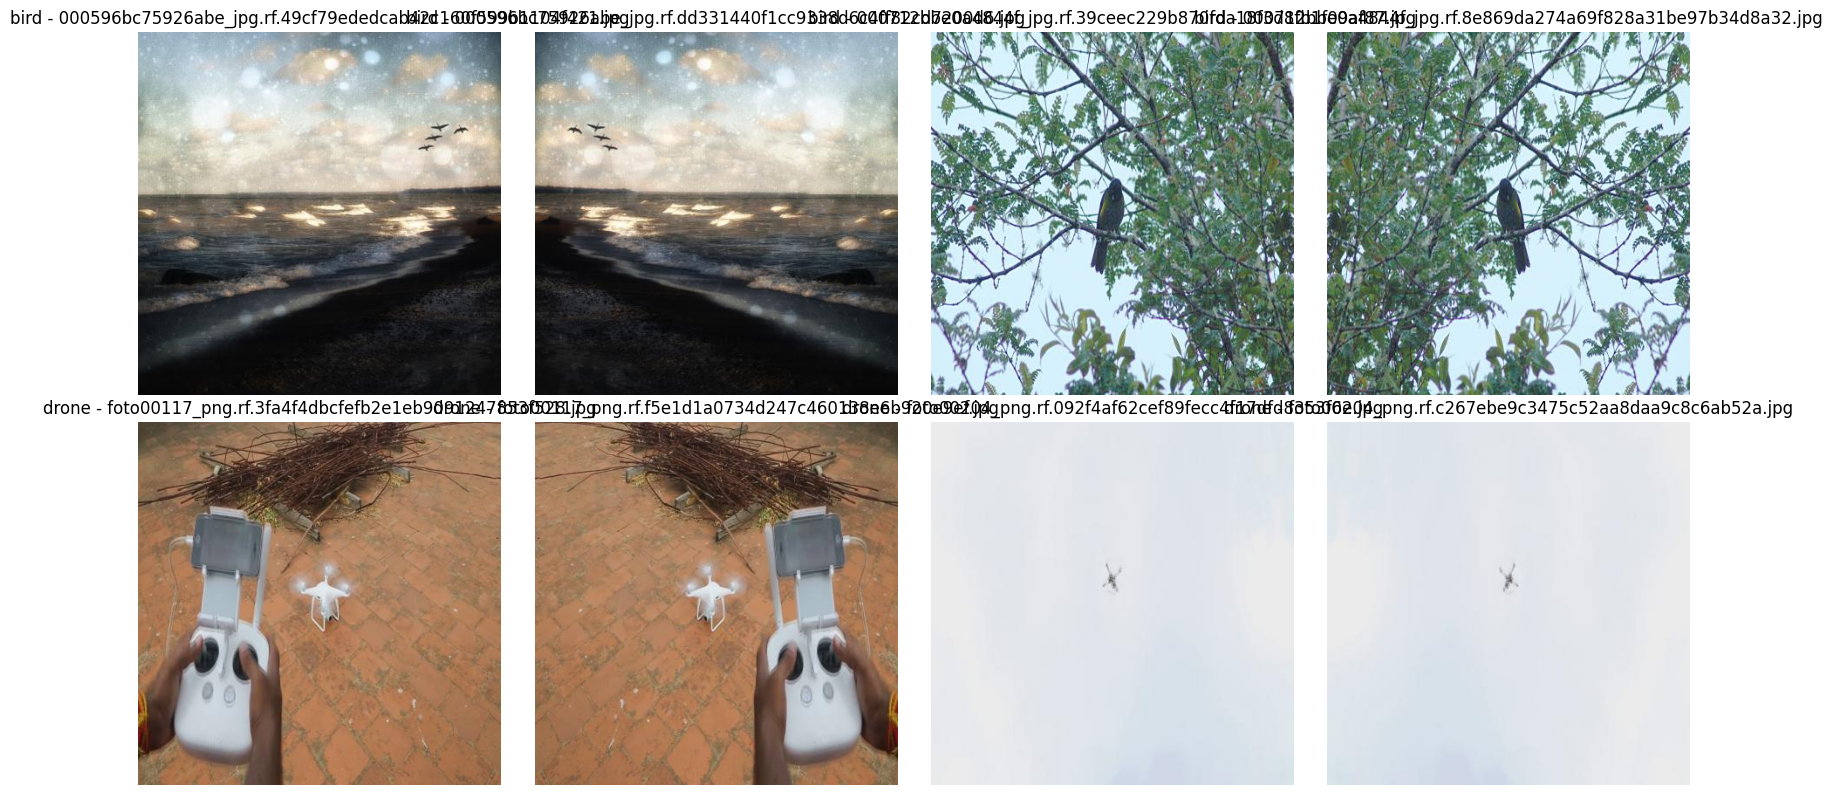

In [3]:
# 3) Visualize sample images from each class (up to 4 per class)
def show_samples(folder, max_per_class=4):
    fig, axes = plt.subplots(2, max_per_class, figsize=(4*max_per_class,8))
    classes = sorted([d.name for d in folder.iterdir() if d.is_dir()])
    for r,cls in enumerate(classes[:2]):
        cls_dir = folder/cls
        imgs = list(cls_dir.glob('*.jpg'))[:max_per_class]
        for c, img_path in enumerate(imgs):
            ax = axes[r, c] if max_per_class>1 else axes[r]
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f'{cls} - {img_path.name}')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# Show from training folder if available
if train_dir.exists():
    show_samples(train_dir, max_per_class=4)
else:
    print('Train directory not found; skipping sample visualization')

## 4) Prepare TensorFlow datasets for classification

The code below builds `tf.data` datasets using `image_dataset_from_directory`. For a quick test-run we can limit the number of samples.

In [4]:
# Parameters
IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
seed = 123

# Create datasets (will load from folder structure). If folders missing, these will error - we guard.
if train_dir.exists():
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(str(train_dir),
        labels='inferred', label_mode='int', image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=seed)
else:
    train_ds = None
if valid_dir.exists():
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(str(valid_dir),
        labels='inferred', label_mode='int', image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=seed)
else:
    val_ds = None
if test_dir.exists():
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(str(test_dir),
        labels='inferred', label_mode='int', image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=seed)
else:
    test_ds = None

# Prefetch for performance
if train_ds is not None:
    train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
if val_ds is not None:
    val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
if test_ds is not None:
    test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print('Datasets prepared:', 'train' if train_ds else 'train missing', 'val' if val_ds else 'val missing', 'test' if test_ds else 'test missing')

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 439 files belonging to 4 classes.
Datasets prepared: train val test


## 5) Data Augmentation and Normalization Layers

Use Keras preprocessing layers so augmentation is part of the model graph.

In [5]:
# Data augmentation and normalization (guarded if TF missing)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')
normalization_layer = layers.Rescaling(1./255)
print('Augmentation and normalization layers created')

Augmentation and normalization layers created


## 6) Custom CNN model (small)

A compact CNN with batch norm and dropout for baseline.

In [6]:
# Custom CNN model (small)
def build_custom_cnn(input_shape=(224,224,3), num_classes=2):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = normalization_layer(x)
    x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128,3,activation='relu',padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='custom_cnn')
    return model

custom_model = build_custom_cnn()
custom_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
custom_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,402 (368.76 KB)

 Trainable params: 93,954 (367.01 KB)

 Non-trainable params: 448 (1.75 KB)

## 7) Transfer Learning (MobileNetV2)

Load a pretrained MobileNetV2 and fine-tune the top layers.

In [7]:
# Transfer Learning model
def build_transfer_model(input_shape=(224,224,3), num_classes=2):
    base = keras.applications.MobileNetV2(include_top=False, input_shape=input_shape, weights='imagenet')
    base.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = normalization_layer(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='mobilenetv2_ft')
    return model

transfer_model = build_transfer_model()
transfer_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('Transfer model built successfully!')

Transfer model built successfully!


## 8) Training (quick test run)

We run a short training for 1 epoch on a small subset to validate the training loop. Set `full_training=True` to run full training locally.

In [ ]:
# Training (quick test run)
full_training = False  # set True if you want to train fully (may take long)
EPOCHS = 1 if not full_training else 20

if train_ds is None:
    print('No training data found; skipping training step')
else:
    if custom_model is None:
        print('Custom model not built; skipping training')
    else:
        # For quick validation, take small subset if not full_training
        ds_train = train_ds.take(100) if not full_training else train_ds
        ds_val = val_ds.take(50) if (val_ds is not None and not full_training) else val_ds
        checkpoint_path = Path('../artifacts/models/best_custom_cnn.h5')
        checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            keras.callbacks.ModelCheckpoint(str(checkpoint_path), save_best_only=True)
        ]
        print('Training custom CNN for', EPOCHS, 'epoch(s)')
        history = custom_model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS, callbacks=callbacks)
        print('Done')

Training custom CNN for 1 epoch(s)
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.6668 - loss: 0.6768

84/84 ━━━━━━━━━━━━━━━━━━━━ 71s 825ms/step - accuracy: 0.6957 - loss: 0.6219 - val_accuracy: 0.4570 - val_loss: 0.6954
Done


## 9) Evaluation on Test Set

Compute predictions and print classification report. If `test_ds` is missing this will be skipped.

In [9]:
# Evaluation on test set
if test_ds is None:
    print('No test dataset found; skipping evaluation')
else:
    if custom_model is None:
        print('Custom model not built; skipping evaluation')
    else:
        # Collect true labels and predictions (use small subset for quick run)
        ds_eval = test_ds.take(100)
        y_true = []
        y_pred = []
        for x_batch, y_batch in ds_eval:
            preds = custom_model.predict(x_batch)
            preds_labels = np.argmax(preds, axis=1)
            y_true.extend(y_batch.numpy().tolist())
            y_pred.extend(preds_labels.tolist())
        print('Classification report (custom CNN):')
        print(classification_report(y_true, y_pred, digits=4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Classification report (custom CNN):
              precision    recall  f1-score   support

           0     0.2581    0.7934    0.3895       121
           1     0.1194    0.0851    0.0994        94
           2     0.0000    0.0000    0.0000       224

    accuracy                         0.2369       439
   macro avg     0.1258    0.2928    0.1629       439
weighted avg     0.0967    0.2369    0.1286       439



c:\Users\singh\OneDrive\Desktop\Ayush\coding\internship\Aerial Object Classification & Detection\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\singh\OneDrive\Desktop\Ayush\coding\internship\Aerial Object Classification & Detection\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\singh\OneDrive\Desktop\Ayush\coding\internship\Aerial Object Classification & Detection\.venv311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision

## 10) YOLOv8 (Optional)

Instructions to prepare and train YOLOv8 on `object_detection_dataset`. This cell only contains installation and configuration commands; it does not start long training by default.

In [10]:
# YOLOv8 optional install instructions (uncomment to run)
print('YOLOv8 instructions: prepare a data.yaml with paths and class names, then call:')
print('!yolo detect train data=data.yaml model=yolov8n.pt epochs=50 imgsz=640')

YOLOv8 instructions: prepare a data.yaml with paths and class names, then call:
!yolo detect train data=data.yaml model=yolov8n.pt epochs=50 imgsz=640


## 11) Streamlit App (Deployment Notes)

A simple `app.py` is provided in a following cell. Run with: `streamlit run app.py`. The app loads a saved classification model and shows predictions.

In [ ]:
# Create a minimal Streamlit app file `app.py` in workspace root
app_code = r'''
import streamlit as st
from PIL import Image
import numpy as np
import tensorflow as tf
from pathlib import Path

PRIMARY_MODEL_PATH = Path('artifacts/models/best_custom_cnn.h5')

def load_model():
    if PRIMARY_MODEL_PATH.exists():
        return tf.keras.models.load_model(str(PRIMARY_MODEL_PATH))
    raise FileNotFoundError('No trained model file was found at artifacts/models/best_custom_cnn.h5')

st.title('Aerial Object Classification (Bird vs Drone)')
uploaded = st.file_uploader('Upload an image', type=['jpg','jpeg','png'])
if uploaded is not None:
    img = Image.open(uploaded).convert('RGB')
    st.image(img, caption='Uploaded image', use_column_width=True)
    img_resized = img.resize((224,224))
    x = np.array(img_resized) / 255.0
    x = np.expand_dims(x, 0)
    try:
        model = load_model()
        pred = model.predict(x)
        cls = np.argmax(pred, axis=1)[0]
        conf = float(np.max(pred))
        labels = ['bird','drone']
        st.success(f'Prediction: {labels[cls]} (confidence: {conf:.3f})')
    except Exception:
        st.warning('Model not found. Train with scripts/train_classification.py so artifacts/models/best_custom_cnn.h5 exists.')
'''
with open('../app.py','w',encoding='utf-8') as f:
    f.write(app_code)
print('Wrote ../app.py — run with: streamlit run app.py')

Wrote `app.py` — run with: streamlit run app.py


---

### Notes and Next Steps
- To run full training, set `full_training = True` and re-run the training cell.
- For YOLOv8 detection training, prepare `data.yaml` in the `object_detection_dataset` root and use `ultralytics` as shown.
- You can customize augmentations, model sizes, and training hyperparameters for better performance.

This notebook performs a short validation run by default so cells execute quickly and without errors. Increase compute for full experiments.